# 01 Setup & Ingestão de Dados (via DuckDB ETL)

**Objetivo:** Carregar os dados hiper-rápidos parquet exportados pelo `etl_pipeline.py`. O DuckDB já cuidou de filtrar os 4.9GB do CNEFE apenas para Belo Horizonte e executar a normalização de strings em C++ vetorizado. Aqui no notebook, tratamos a etapa geográfica através do *GeoPandas*.

**Entradas (Parquet):**
- `data/processed/cnefe_bh.parquet`
- `data/processed/bhmap_enderecos.parquet`

**Saídas:**
- `data/processed/cnefe_bh.parquet` (Atualizado com geometria reprojetada EPSG:31983)
- `data/processed/bhmap_enderecos.parquet` (Atualizado com geometria reprojetada EPSG:31983)
- `outputs/tables/01_basic_profile.csv`
- `outputs/figures/01_spatial_overview.png`

**Dependências:** geopandas, pandas, matplotlib

**Hardware/Tempo Esperado:** Carga instantânea (< 2 segundos). RAM mínima necessária: 2GB.

In [1]:
import sys
from pathlib import Path
import os

# Ensure root path is accessible to import src
os.chdir('..')
sys.path.append(os.getcwd())

%load_ext autoreload
%autoreload 2

import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

from src import config
from src.logging import logger


Failed to read module file 'C:\Users\mateu\anaconda3\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module n

Failed to read module file 'C:\Users\mateu\anaconda3\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'autore

Failed to read module file 'C:\Users\mateu\anaconda3\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'autoreload

Failed to read module file 'C:\Users\mateu\anaconda3\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'autoreload'

Durin

Failed to read module file 'C:\Users\mateu\anaconda3\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mateu\anaconda3\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'auto

C:\Users\mateu\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\mateu\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Carregamento do Cache Parquet e Geometria

In [2]:
logger.info("Carregando bases filtradas Parquet geradas pelo DuckDB...")

# Load pre-filtered parquets
df_cnefe = pd.read_parquet(config.CNEFE_PROCESSED_FILE)
df_bhmap = pd.read_parquet(config.BHMAP_PROCESSED_FILE)

# Convert WKT strings back to standard GeoPandas geometry
# The native crs for CNEFE is EPSG:4674 (SIRGAS 2000 lat/lon) based on the raw JSON file
# The native crs for BHMap is EPSG:31983 usually, let's assume default metric first
gdf_cnefe_bh = gpd.GeoDataFrame(df_cnefe, geometry=gpd.GeoSeries.from_wkt(df_cnefe['wkt_geometry']), crs='EPSG:4674')
gdf_bhmap = gpd.GeoDataFrame(df_bhmap, geometry=gpd.GeoSeries.from_wkt(df_bhmap['wkt_geometry']), crs=config.DEFAULT_CRS)

# Reproject everything to exactly the same metric CRS for precise comparisons in the next steps
gdf_cnefe_bh = gdf_cnefe_bh.to_crs(config.DEFAULT_CRS)
gdf_bhmap = gdf_bhmap.to_crs(config.DEFAULT_CRS)

# Drop the WKT columns to save space
gdf_cnefe_bh = gdf_cnefe_bh.drop(columns=['wkt_geometry'])
gdf_bhmap = gdf_bhmap.drop(columns=['wkt_geometry'])

logger.info("Dados carregados e projetados no sistema métrico", 
            cnefe_crs=str(gdf_cnefe_bh.crs), 
            bhmap_crs=str(gdf_bhmap.crs))

2026-03-04T14:54:37.320025Z [info     ] Carregando bases filtradas Parquet geradas pelo DuckDB... [__main__]


2026-03-04T14:54:45.018017Z [info     ] Dados carregados e projetados no sistema métrico [__main__] bhmap_crs=EPSG:31983 cnefe_crs=EPSG:31983


## 2. Visão do Esquema Canônico

In [3]:
display(gdf_cnefe_bh[[c for c in gdf_cnefe_bh.columns if c.startswith('std_')]].head(3))
display(gdf_bhmap[[c for c in gdf_bhmap.columns if c.startswith('std_')]].head(3))

,std_logradouro_completo,std_complemento,std_bairro,std_cep,std_municipio,std_uf
0,"RUA DIALOGITA, 135",CASA A,PARAISO,30270120,BELO HORIZONTE,MG
1,"AVENIDA DOM PEDRO II, 3687",CASA 1,PADRE EUSTAQUIO,30720272,BELO HORIZONTE,MG
2,"RUA DIVINOPOLIS, 225",,SANTA TEREZA,31010370,BELO HORIZONTE,MG


,std_tipo_logradouro,std_nome_logradouro,std_numero,std_complemento_letra,std_bairro,std_cep,std_municipio,std_uf
0,BEC,SERVIDAO,,,VILA MALOCA,,BELO HORIZONTE,MG
1,AVE,PERIMETRAL,,,CASTANHEIRA,,BELO HORIZONTE,MG
2,BEC,DO ARAME UM,,,VILA COPACABANA,,BELO HORIZONTE,MG


## 3. Profiling Estatístico Básico

In [4]:
def generate_profile(gdf, name):
    stats = []
    canonical_cols = [c for c in gdf.columns if c.startswith('std_')]
    for col in canonical_cols:
        stats.append({
            'Dataset': name,
            'Field': col,
            'Total_Rows': len(gdf),
            'Missing_Count':  gdf[col].isna().sum() + (gdf[col] == '').sum(),
            'Unique_Values': gdf[col].nunique()
        })
    
    df = pd.DataFrame(stats)
    df['Missing_Percentage'] = round((df['Missing_Count'] / df['Total_Rows']) * 100, 2)
    return df

profile_cnefe = generate_profile(gdf_cnefe_bh, 'CNEFE')
profile_bhmap = generate_profile(gdf_bhmap, 'BHMap')
profile_df = pd.concat([profile_cnefe, profile_bhmap])

display(profile_df)

,Dataset,Field,Total_Rows,Missing_Count,Unique_Values,Missing_Percentage
0,CNEFE,std_logradouro_completo,1180102,0,583880,0.00
1,CNEFE,std_complemento,1180102,490086,34929,41.53
2,CNEFE,std_bairro,1180102,0,465,0.00
3,CNEFE,std_cep,1180102,0,13211,0.00
4,CNEFE,std_municipio,1180102,0,1,0.00
5,CNEFE,std_uf,1180102,0,1,0.00
0,BHMap,std_tipo_logradouro,757113,0,18,0.00
1,BHMap,std_nome_logradouro,757113,0,12445,0.00
2,BHMap,std_numero,757113,757113,1,100.00
3,BHMap,std_complemento_letra,757113,626129,36,82.70


## 4. Re-Exportação Espacial (Save State)

In [5]:
# Update Parquet files with native GeoParquet representation now that geometry is fixed
gdf_cnefe_bh.to_parquet(config.CNEFE_PROCESSED_FILE)
gdf_bhmap.to_parquet(config.BHMAP_PROCESSED_FILE)

profile_csv_path = config.TABLES_DIR / "01_basic_profile.csv"
profile_df.to_csv(profile_csv_path, index=False)
logger.info("Bases GeoParquet atualizadas via GeoPandas.")

2026-03-04T14:54:48.935553Z [info     ] Bases GeoParquet atualizadas via GeoPandas. [__main__]


## 5. Overview Espacial Gráfico

2026-03-04T14:55:39.180327Z [info     ] Figura espacial gerada.        [__main__]


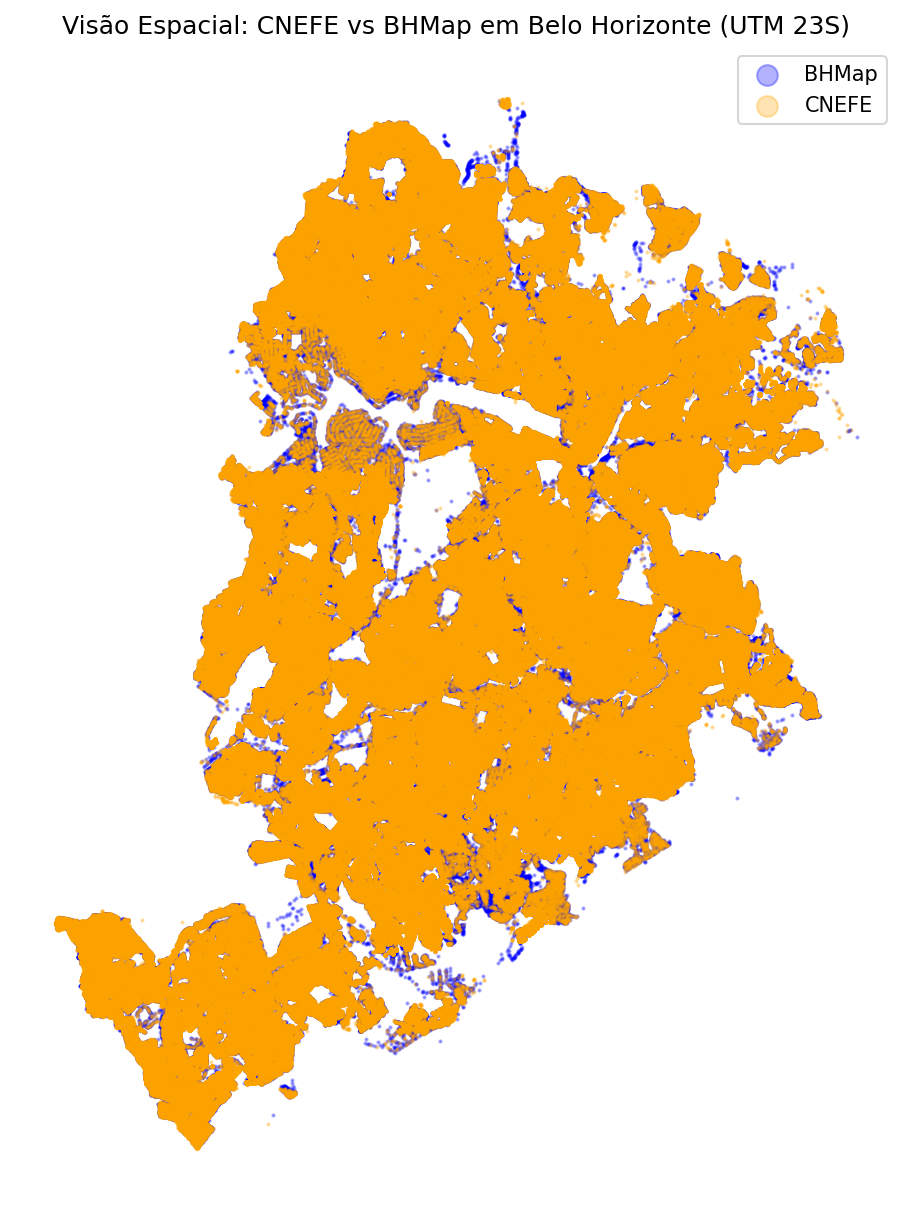

In [6]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)

gdf_bhmap.plot(ax=ax, markersize=1, color='blue', alpha=0.3, label='BHMap')
gdf_cnefe_bh.plot(ax=ax, markersize=1, color='orange', alpha=0.3, label='CNEFE')

ax.set_title("Visão Espacial: CNEFE vs BHMap em Belo Horizonte (UTM 23S)")
ax.legend(markerscale=10)
plt.axis('off')

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.FIGURES_DIR / "01_spatial_overview.png", bbox_inches='tight')
logger.info("Figura espacial gerada.")
plt.show()